In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px 
import warnings
warnings.filterwarnings('ignore')
%pip install openpyxl


Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
df = pd.read_csv("C:/Users/Jagdish singh/projects/datasets/usa_visa.csv")

In [3]:
df.columns

Index(['add_these_pw_job_title_9089', 'agent_city', 'agent_firm_name',
       'agent_state', 'application_type', 'case_no', 'case_number',
       'case_received_date', 'case_status', 'class_of_admission',
       ...
       'ri_pvt_employment_firm_to', 'ri_us_workers_considered',
       'schd_a_sheepherder', 'us_economic_sector', 'wage_offer_from_9089',
       'wage_offer_to_9089', 'wage_offer_unit_of_pay_9089',
       'wage_offered_from_9089', 'wage_offered_to_9089',
       'wage_offered_unit_of_pay_9089'],
      dtype='object', length=154)

In [4]:
# cas_no and cas number noth have same things

In [5]:
df.shape

(374362, 154)

In [6]:
df.case_no

0         A-07323-97014
1         A-07332-99439
2         A-07333-99643
3         A-07339-01930
4         A-07345-03565
              ...      
374357              NaN
374358              NaN
374359              NaN
374360              NaN
374361              NaN
Name: case_no, Length: 374362, dtype: object

In [7]:
df.case_number

0                   NaN
1                   NaN
2                   NaN
3                   NaN
4                   NaN
              ...      
374357    A-16363-85407
374358    A-16271-56745
374359    A-16354-82345
374360    A-16357-84250
374361    A-16279-59292
Name: case_number, Length: 374362, dtype: object

In [8]:
df.case_no.nunique()
df.case_number.nunique()

238418

In [9]:
df.case_no.isnull().sum()
df.case_number.isnull().sum()

np.int64(135269)

In [10]:
casenoindex = df.columns.get_loc('case_no')
casenumberindex = df.columns.get_loc('case_number')

casenumberlist = []
for value in df.iloc[0:135269, casenoindex]:
    casenumberlist.append(value)
    
for value in df.iloc[135269:374362, casenumberindex]:
    casenumberlist.append(value)
    

In [ ]:
'''df['final_case_number'] = (
    df['case_no'].fillna(df['case_number'])
)'''


In [ ]:
casenumberlist

In [12]:
df['casenumber']=casenumberlist

In [13]:
df.drop(['case_no','case_number'],axis=1,inplace=True)

In [14]:
df.case_status.value_counts()

case_status
Certified            181933
Certified-Expired    148586
Denied                25649
Withdrawn             18194
Name: count, dtype: int64

In [15]:
for value in df.case_status.unique():
    print(len(df[df['case_status']==value]),"occurence of stats '{}'".format(value))

181933 occurence of stats 'Certified'
25649 occurence of stats 'Denied'
148586 occurence of stats 'Certified-Expired'
18194 occurence of stats 'Withdrawn'


In [16]:
df['case_status'] = df['case_status'].replace({
    'Certified-Expired': 'Certified',
    'Withdrawn': 'Denied'
})
df.case_status.value_counts()



case_status
Certified    330519
Denied        43843
Name: count, dtype: int64

In [ ]:
'''df['case_status'] = df['case_status'].replace(
    to_replace={
        'Certified-Expired': 'Certified',
        'Withdrawn': 'Denied'
    }
)'''


In [17]:
df.case_status.value_counts(normalize=True)*100

case_status
Certified    88.288608
Denied       11.711392
Name: proportion, dtype: float64

In [ ]:
df.isnull().sum()

In [18]:
df.dropna(inplace=True,axis=1,how='all')
df.dropna(inplace=True,axis=0,how='all')

In [19]:
df.isnull().sum()

add_these_pw_job_title_9089      332168
agent_city                       162908
agent_firm_name                  167365
agent_state                      166123
application_type                 239093
                                  ...  
wage_offer_unit_of_pay_9089      115916
wage_offered_from_9089           259715
wage_offered_to_9089             343347
wage_offered_unit_of_pay_9089    303663
casenumber                            0
Length: 153, dtype: int64

In [20]:
df.decision_date.dtype

dtype('O')

In [21]:
df['decision_date'] = pd.to_datetime(df['decision_date'], errors='coerce')


In [22]:
df['year']  = df['decision_date'].dt.year
df['month'] = df['decision_date'].dt.month
df['date']  = df['decision_date'].dt.day


In [23]:
df[['year', 'month', 'date']]
df[['year', 'month', 'date']].dtypes


year     int32
month    int32
date     int32
dtype: object

In [24]:
'''df.year=df.decision_date.apply(lambda x:x.split('-')[0])
df.month=df.decision_date.apply(lambda x:x.split('-')[1])
df.date=df.decision_date.apply(lambda x:x.split('-')[2])'''

"df.year=df.decision_date.apply(lambda x:x.split('-')[0])\ndf.month=df.decision_date.apply(lambda x:x.split('-')[1])\ndf.date=df.decision_date.apply(lambda x:x.split('-')[2])"

In [25]:
'''df.decision_date=pd.to_datetime(df['decision_date'])
df.yearly=df.decision_date.dt.year
df.yearly'''

"df.decision_date=pd.to_datetime(df['decision_date'])\ndf.yearly=df.decision_date.dt.year\ndf.yearly"

In [ ]:
df.drop('decision_date',inplace=True,axis=1)

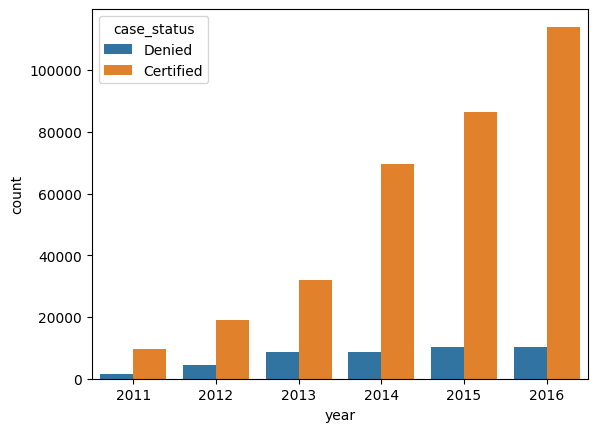

In [26]:
sns.countplot(x=df.year,data=df,hue='case_status')
plt.show()

In [27]:
df.employer_city.unique()

array(['NEW YORK', 'CARLSTADT', 'GLEN ALLEN', ..., 'austin',
       'Carson City', 'Northfield'], shape=(8385,), dtype=object)

In [28]:
df.employer_city.value_counts() 

employer_city
NEW YORK            16730
COLLEGE STATION     12118
SANTA CLARA         11113
SAN JOSE             9349
REDMOND              8804
                    ...  
Forest Lake             1
South Burlington        1
Maumelle                1
NEW KNOXVILLE,          1
DICKERSON               1
Name: count, Length: 8384, dtype: int64

In [ ]:
df.employer_city=df.employer_city.str.upper()
df.employer_city.unique()

In [31]:
#empolyeer city yearwise traveling visa
df.date

0          1
1         21
2          1
3          1
4         26
          ..
374357    30
374358    30
374359    30
374360    30
374361    30
Name: date, Length: 374362, dtype: int32

In [ ]:
'''sns.countplot(x='employer_city',data=df,hue='year')
plt.show()'''

In [ ]:
df.date,df.year,df.month

In [33]:
df['date'] = df['date'].astype(int)
df['month'] = df['month'].astype(int)
df['year'] = df['year'].astype(int)


In [35]:
df[['year','date','month']]


,year,date,month
0,2012,1,2
1,2011,21,12
2,2011,1,12
3,2011,1,12
4,2012,26,1
...,...,...,...
374357,2016,30,12
374358,2016,30,12
374359,2016,30,12
374360,2016,30,12


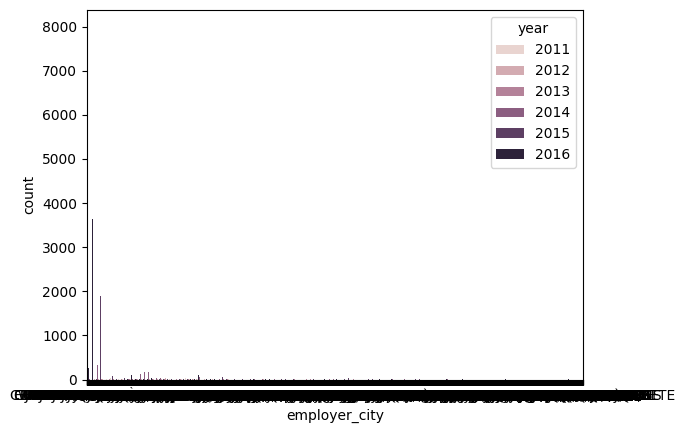

In [36]:
sns.countplot(x=df.employer_city,data=df,hue='year')
plt.show()

In [ ]:
top_cities = df['employer_city'].value_counts().head(10).index
df_top = df[df['employer_city'].isin(top_cities)]


plt.figure(figsize=(12,6))
sns.countplot(
    data=df_top,
    x='employer_city',
    hue='year'
)
plt.xticks(rotation=45)
plt.title('Top 10 Employer Cities')
plt.tight_layout()
plt.show()


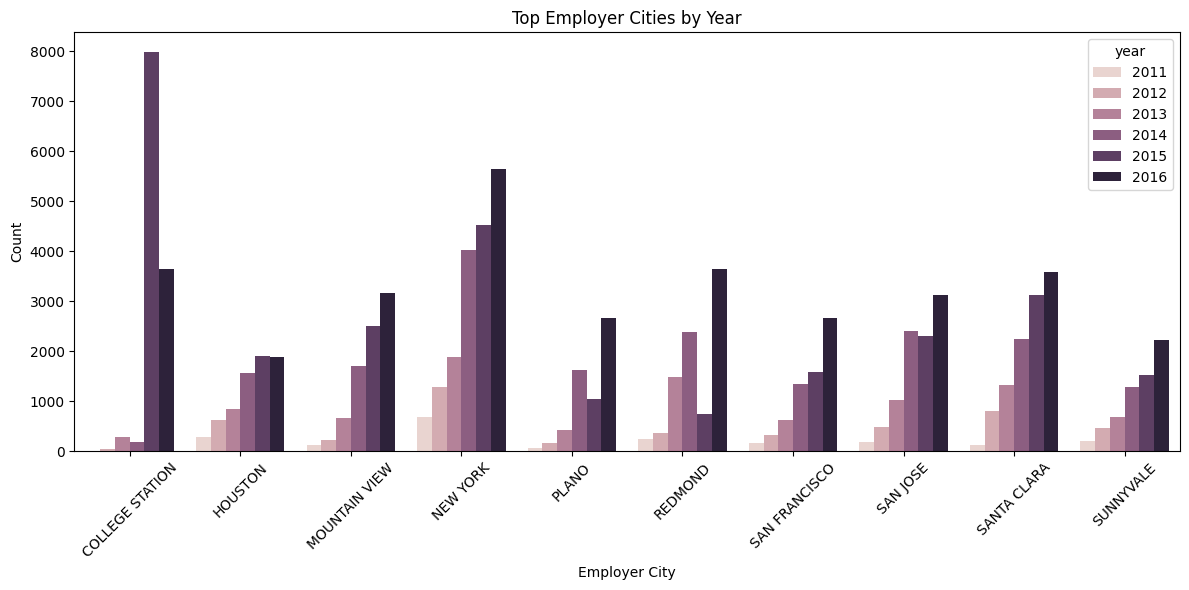

In [38]:
# Aggregate data
agg_df = (
    df_top
    .groupby(['employer_city', 'year'])
    .size()
    .reset_index(name='count')
)

plt.figure(figsize=(12,6))
sns.barplot(
    data=agg_df,
    x='employer_city',
    y='count',
    hue='year'
)

plt.xticks(rotation=45)
plt.xlabel("Employer City")
plt.ylabel("Count")
plt.title("Top Employer Cities by Year")
plt.tight_layout()
plt.show()


In [ ]:
'''df['decision_date'] = df['decision_date'].astype(str)
df['year'] = df['decision_date'].apply(lambda x: x.split('-')[0])
df['month'] = df['decision_date'].apply(lambda x: x.split('-')[1])
df['date'] = df['decision_date'].apply(lambda x: x.split('-')[2])
df['year'] = df['year'].astype(int)
df['month'] = df['month'].astype(int)
df['date'] = df['date'].astype(int)'''



In [ ]:
#top 10 employer via visa name
df.employer_name


In [ ]:
top_employers = df['employer_name'].value_counts().head(10).index
df_top = df[df['employer_name'].isin(top_employers)]

'''Counts how many times each employer appears in the dataset
Selects the top 10 most frequent employers
Extracts only their names Filters the original DataFrame
Keeps only rows where employer is in the top 10 list'''



In [ ]:
df.application_type.value_counts()

In [ ]:
plt.figure(figsize=(12,6))
sns.countplot(
    data=df_top,
    x='employer_name',
    hue='application_type'
)
plt.xticks(rotation=45)
plt.title('Top 10 Employers by Application Type')
plt.tight_layout()
plt.show()

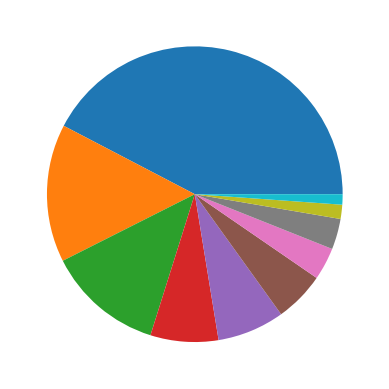

In [44]:
df.us_economic_sector.dropna()
x=df.us_economic_sector.value_counts().head(10)
plt.pie(x)
plt.show()

In [41]:
us_economic_counts={}
for value in df.us_economic_sector:
    if value in us_economic_counts:
        us_economic_counts[value]+=1
    else:
        us_economic_counts[value]=1

us_economic_counts


{'IT': 52617,
 'Other Economic Sector': 15798,
 'Aerospace': 4166,
 'Advanced Mfg': 18749,
 'Educational Services': 9130,
 'Retail': 4408,
 'Construction': 1409,
 'Hospitality': 1926,
 'Automotive': 1163,
 nan: 10196,
 'Health Care': 6825,
 'Agribusiness': 939,
 'Finance': 9224,
 'Energy': 1086,
 'Transportation': 949,
 'Homeland Security': 82,
 'Biotechnology': 456,
 'Geospatial': 141,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1,
 nan: 1

In [ ]:
#numbers as key , names of sector as list

In [42]:
usecollabels=[]
usecolvalues=[]
for key,value in us_economic_counts.items():
    usecollabels.append(key)
    usecolvalues.append(value)

usecolvalues
    

[52617,
 15798,
 4166,
 18749,
 9130,
 4408,
 1409,
 1926,
 1163,
 10196,
 6825,
 939,
 9224,
 1086,
 949,
 82,
 456,
 141,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [ ]:
usecollabels

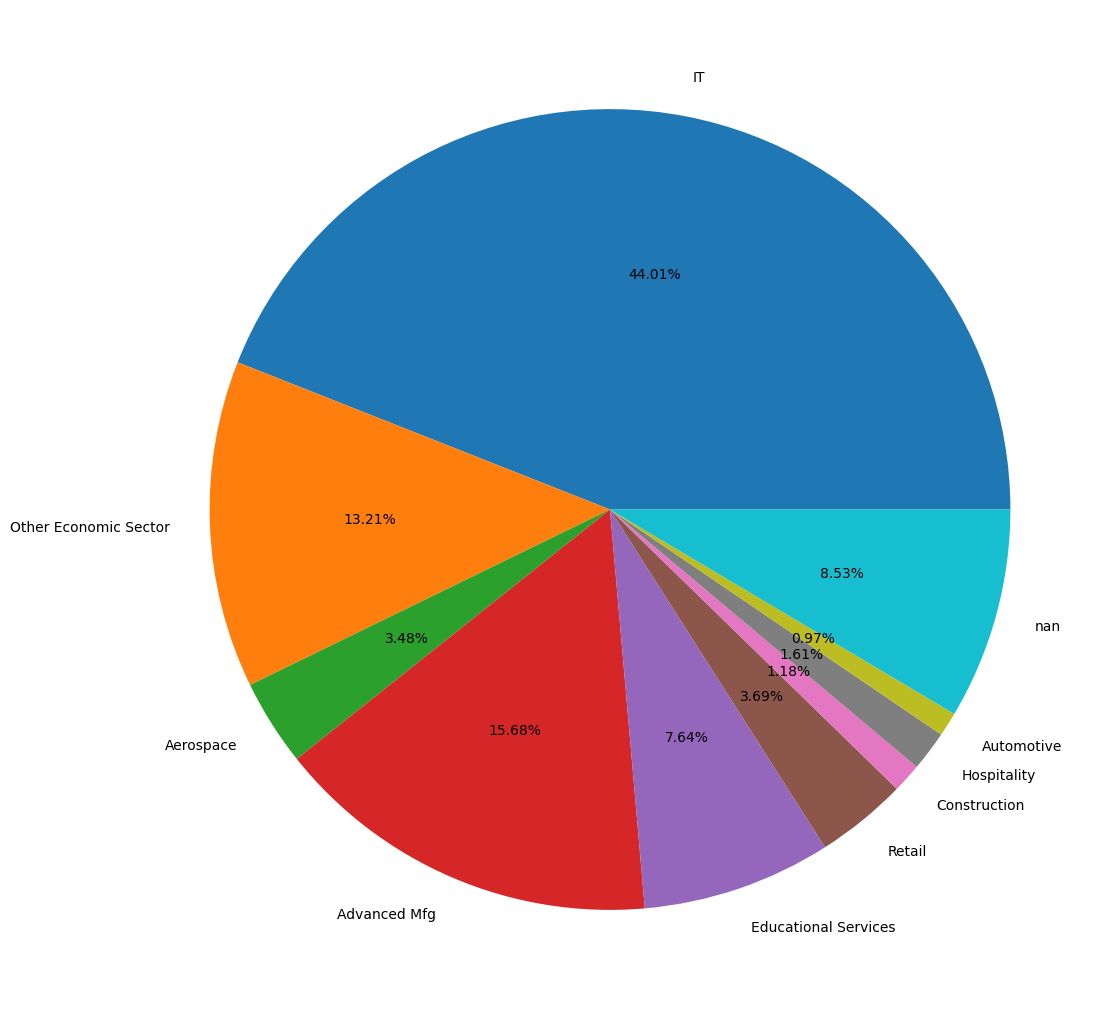

In [43]:
plt.figure(figsize=(13,13))
plt.pie(usecolvalues[:10],labels=usecollabels[:10],autopct='%1.2f%%')
plt.show()

In [ ]:
df['job_info_job_title'].replace({
    'software engineer': 'Software Engineer',
    'SOFTWARE ENGINEER': 'Software Engineer',
    'Senior Software Engineer': 'Software Engineer'
}, inplace=True)


In [ ]:
df.job_info_job_title = df.job_info_job_title.replace(
    ['software engineer', 'Software Engineer', 'SOFTWARE ENGINEER', 'senior software engineer'],
    'Software Engineer'
)

In [ ]:
df.job_info_job_title=df.job_info_job_title.replace(['Computer Systems Analyst - V','Computer Systems Analyst - II','Computer Systems Analyst - IV','Computer Systems Analyst - III'],'Computer Systems Analyst')

In [ ]:
top_jobs = df['job_info_job_title'].value_counts().head(10)
#top_jobs is a Series where index = job titles and values = counts.

In [ ]:
plt.figure(figsize=(10,6))
sns.barplot(y=top_jobs.values, x=top_jobs.index, palette='viridis')  # Horizontal bars

# Add title and labels
plt.xlabel('Number of Jobs', fontsize=12)
plt.ylabel('Job Titles', fontsize=12)
plt.title('Top 10 Job Titles', fontsize=14)
plt.show()



In [ ]:
plt.pie(top_jobs,autopct='%1.2ff%%')
plt.show()

In [ ]:
'''#get the top 10 job titles by count
top_job_titles = df.job_info_job_title.value_counts().head(10)
#create a bar plot
plt.figure(figsize = (12.7, 8.3))
plt.bar(top_job_titles.index, top_job_titles,  color=sns.color_palette("viridis", len(top_job_titles)))

#add count labels above the bar
for i, v in enumerate(top_job_titles):
    plt.text(i, v + 10, str(v), ha='center', va='bottom', fontsize=10, rotation=90)
    
plt.xlabel("Job title")
plt.ylabel("Number of visa application")
plt.title("Top 10 job titles by visa application")
plt.xticks(rotation = 90)
plt.tight_layout()
plt.show()'''

In [ ]:
df.country_of_citizenship.value_counts()

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Step 1: Get top 10 countries
top_countries = df['country_of_citizenship'].value_counts().head(10).index

# Step 2: Filter dataframe to only include top 10
df_top = df[df['country_of_citizenship'].isin(top_countries)]

# Step 3: Plot countplot
plt.figure(figsize=(12,6))
sns.countplot(
    x='country_of_citizenship', 
    data=df_top, 
    hue='case_status', 
    order=top_countries,   # ensures same order as value_counts
    palette='viridis'
)

plt.xticks(rotation=45)  # Rotate labels for readability
plt.xlabel('Country of Citizenship', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.title('Top 10 Countries by Cases with Case Status', fontsize=14)
plt.legend(title='Case Status')
plt.show()


In [ ]:
top_countries = df['country_of_citizenship'].value_counts().head(10).index
df_topcont=df[df['country_of_citizenship'].isin(top_countries)]

sns.barplot(top_countries.index,top_countries.values,data=df_topcont,hue='case_status')
plt.show()

In [ ]:
top_countries = df['country_of_citizenship'].value_counts().head(10).index
df_topcont = df[df['country_of_citizenship'].isin(top_countries)]

In [ ]:
#converting data to categorical data
#df.country_of_citizenship=pd.Categorical(df.country_of_citizenship)


In [ ]:
df.application_type

In [ ]:
top_application = df['application_type'].value_counts().head(10).index

# Step 2: Filter dataframe to only include top 10
df_top = df[df['application_type'].isin(top_application)]

# Step 3: Plot countplot
plt.figure(figsize=(12,6))
sns.countplot(
    x='application_type', 
    data=df_top,
    order=top_application,   # ensures same order as value_counts
    palette='viridis'
)

plt.xticks(rotation=45)  # Rotate labels for readability
plt.xlabel('Country of Citizenship', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.title('Top 10 Countries by Cases with Case Status', fontsize=14)
plt.legend(title='Case Status')
plt.show()

In [ ]:
plt.figure(figsize=(12,6))
ax = sns.countplot(
    x='application_type',
    data=df_top,
    order=top_application,
    palette='viridis'
)
for container in ax.containers:
    ax.bar_label(container)
plt.xticks(rotation=45)
plt.xlabel('Application Type')
plt.ylabel('Number of Applications')
plt.title('Top 10 Application Types')
plt.show()

In [ ]:
df.foreign_worker_info_education.value_counts()

In [ ]:
top_education = df['foreign_worker_info_education'].value_counts().head(10).index

# Step 2: Filter dataframe to only include top 10
df_top = df[df['foreign_worker_info_education'].isin(top_education)]

plt.figure(figsize=(12,6))
sns.countplot(
    x='foreign_worker_info_education', 
    data=df_top, 
    hue='case_status',
  # ensures same order as value_counts
    palette='viridis'
)
plt.xticks(rotation=45)  # Rotate labels for readability
plt.xlabel('Country of Citizenship', fontsize=12)
plt.ylabel('Number of Cases', fontsize=12)
plt.title('Top 10 Countries by Cases with Case Status', fontsize=14)
plt.legend(title='Case Status')
plt.show()


In [ ]:
df.case_status=df.case_status.replace(['Certified','Denied'],[1,0])
df.case_status

In [ ]:
df.employer_state.isnull().sum()
df.employer_state.mode()[0]
df.employer_state=df.employer_state.fillna(df.employer_state.mode()[0])
df.employer_state.isnull().sum()

In [ ]:
#percentage of non null values
i = 0;
for col in df.columns:
    i = i+1;
    print (i-1,"Column: '{}'".format(col),"contains ", np.round(100*df[col].count()/len(df['case_status']),decimals=2),"% non-null values" )

In [ ]:
#keep the columns with non null values count > 33000
df = df.loc[:, df.count()>= 330000]
df.info()

In [ ]:
df.loc[df['case_status'] == 'Certified', 'case_status'] =1
df.loc[df['case_status'] == 'Denied', 'case_status'] =0

In [ ]:
df['employer_state'].isnull().sum()

In [ ]:
df['employer_state']

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np

# Dictionary for mapping state names to abbreviations
state_abbrevs = {
    'Alabama': 'AL',
    'Alaska': 'AK',
    'Arizona': 'AZ',
    'Arkansas': 'AR',
    'California': 'CA',
    'Colorado': 'CO',
    'Connecticut': 'CT',
    'Delaware': 'DE',
    'Florida': 'FL',
    'Georgia': 'GA',
    'Hawaii': 'HI',
    'Idaho': 'ID',
    'Illinois': 'IL',
    'Indiana': 'IN',
    'Iowa': 'IA',
    'Kansas': 'KS',
    'Kentucky': 'KY',
    'Louisiana': 'LA',
    'Maine': 'ME',
    'Maryland': 'MD',
    'Massachusetts': 'MA',
    'Michigan': 'MI',
    'Minnesota': 'MN',
    'Mississippi': 'MS',
    'Missouri': 'MO',
    'Montana': 'MT',
    'Nebraska': 'NE',
    'Nevada': 'NV',
    'New Hampshire': 'NH',
    'New Jersey': 'NJ',
    'New Mexico': 'NM',
    'New York': 'NY',
    'North Carolina': 'NC',
    'North Dakota': 'ND',
    'Ohio': 'OH',
    'Oklahoma': 'OK',
    'Oregon': 'OR',
    'Pennsylvania': 'PA',
    'Rhode Island': 'RI',
    'South Carolina': 'SC',
    'South Dakota': 'SD',
    'Tennessee': 'TN',
    'Texas': 'TX',
    'Utah': 'UT',
    'Vermont': 'VT',
    'Virginia': 'VA',
    'Washington': 'WA',
    'West Virginia': 'WV',
    'Wisconsin': 'WI',
    'Wyoming': 'WY',
    'Northern Mariana Islands':'MP',
    'Palau': 'PW',
    'Puerto Rico': 'PR',
    'Virgin Islands': 'VI',
    'District of Columbia': 'DC'
}

# Reverse dictionary for abbreviation to state name mapping
abbrev_to_state = {v: k.upper() for k, v in state_abbrevs.items()}

# Clean and transform employer_state column in DataFrame
df['employer_state'] = df['employer_state'].fillna('').astype(str).str.strip().str.upper()

# Replace abbreviations with full state names
df['employer_state'] = df['employer_state'].replace(abbrev_to_state)


In [ ]:
df['employer_state']

In [ ]:
df.pw_soc_code

In [ ]:
df['pw_soc_code'] = df['pw_soc_code'].str.replace('.','')
df['pw_soc_code'] = df['pw_soc_code'].str.replace('-','')
df['pw_soc_code'] = df['pw_soc_code'].astype(str).str[0:6]
df['pw_soc_code'].value_counts()

#Finding "nan" values in "pw_soc_code" column and filling them with mode
df.loc[df['pw_soc_code'] == "nan",'pw_soc_code'] = df['pw_soc_code'].mode()[0]

#Finding "None" values in "pw_soc_code" column and filling them with mode
df.loc[df['pw_soc_code'] == "None",'pw_soc_code'] = df['pw_soc_code'].mode()[0]

#Changing type from string to int
df['pw_soc_code'] = df['pw_soc_code'].astype(int)
df['case_status'] = df['case_status'].astype(int)

In [ ]:
df['case_status']

In [ ]:
#missing value treatment for other columns

#Replacing missing values with mode
df['class_of_admission']=df['class_of_admission'].fillna((df['class_of_admission'].mode()[0]))
df['country_of_citizenship']=df['country_of_citizenship'].fillna((df['country_of_citizenship'].mode()[0]))
df['employer_city']=df['employer_city'].fillna((df['employer_city'].mode()[0]))
df['employer_name']=df['employer_name'].fillna((df['employer_name'].mode()[0]))
df['employer_name']=df['employer_name'].astype(str).str.upper()
df['pw_source_name_9089']=df['pw_source_name_9089'].fillna((df['pw_source_name_9089'].mode()[0]))

In [ ]:
df.info()

In [ ]:
# Convert the column containing numerical values with commas to numeric format
df['pw_amount_9089'] = df['pw_amount_9089'].str.replace(',', '').astype(float)

# Now, you can replace null values in the numerical column with the median
median_pw_amount = df['pw_amount_9089'].median()
df['pw_amount_9089'].fillna(median_pw_amount, inplace=True)

# Verify that there are no more null values
print(df.isnull().sum())

In [ ]:
#Indices of selected features for categorcal data to do encoding
chosen_attrs = [0,1,2,5,6,8,12,14,17]
df = df.iloc[:,chosen_attrs]

In [ ]:
from sklearn.preprocessing import LabelEncoder

categorical_variables = {}

cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    le = LabelEncoder()
    df[col] = df[col].astype(str)   # ensures uniform type
    df[col] = le.fit_transform(df[col])
    categorical_variables[col] = le


In [ ]:


df.info()

In [ ]:
df